<a href="https://colab.research.google.com/github/tepherve-cmyk/DAAI_Project_HT/blob/main/Projet1_Herve_Tepongning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Herve Tepongning Megnifo

Student Number: HT137724

Program: Business Intelligence Analyst

Course: Introduction to Artificial Intelligence

## FINAL PROJECT
#Project Part 1

In [ ]:
# Python libraries
import pandas as pd


In [ ]:
# Loading the Dataset

# Connect Google Drive
from google.colab import drive

drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load the dataset

import pandas as pd

prices_path = '/content/drive/MyDrive/Drive_Colab/historical_stock_prices.csv'
stock_path = '/content/drive/MyDrive/Drive_Colab/historical_stocks.csv'

#df_prices = pd.read_csv('historical_stock_prices.csv', dtype=dtypes, parse_dates=['date'])

dtypes = {
    'ticker': 'category',
    'open': 'float32',
    'high': 'float32',
    'low': 'float32',
    'close': 'float32',
    'adj_close': 'float32',
    'volume': 'int64'
}

df_prices = pd.read_csv(prices_path, dtype=dtypes, parse_dates=['date'])
df_stocks = pd.read_csv(stock_path)




In [ ]:

# Display first rows
print("The first five rows of the historical stock price dataset:")

print("\n",df_prices.head())


The first five rows of the historical stock price dataset:

   ticker   open  close  adj_close    low   high   volume       date
0    AHH  11.50  11.58   8.493155  11.25  11.68  4633900 2013-05-08
1    AHH  11.66  11.55   8.471151  11.50  11.66   275800 2013-05-09
2    AHH  11.55  11.60   8.507822  11.50  11.60   277100 2013-05-10
3    AHH  11.63  11.65   8.544494  11.55  11.65   147400 2013-05-13
4    AHH  11.60  11.53   8.456484  11.50  11.60   184100 2013-05-14


In [ ]:
print("The first five rows of the historical_stocks dataset:")

print("\n",df_stocks.head())

The first five rows of the historical_stocks dataset:

   ticker exchange                                    name             sector  \
0    PIH   NASDAQ  1347 PROPERTY INSURANCE HOLDINGS, INC.            FINANCE   
1  PIHPP   NASDAQ  1347 PROPERTY INSURANCE HOLDINGS, INC.            FINANCE   
2   TURN   NASDAQ                180 DEGREE CAPITAL CORP.            FINANCE   
3   FLWS   NASDAQ                 1-800 FLOWERS.COM, INC.  CONSUMER SERVICES   
4   FCCY   NASDAQ           1ST CONSTITUTION BANCORP (NJ)            FINANCE   

                     industry  
0  PROPERTY-CASUALTY INSURERS  
1  PROPERTY-CASUALTY INSURERS  
2  FINANCE/INVESTORS SERVICES  
3      OTHER SPECIALTY STORES  
4        SAVINGS INSTITUTIONS  


In [ ]:
# Display the Shape of the Dataset

print("historical stock prices:", df_prices.shape)
print("historical_stocks", df_stocks.shape)


historical stock prices: (20973889, 8)
historical_stocks (6460, 5)


In [ ]:
# Display dataset informations

print("historical stock prices:", df_prices.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20973889 entries, 0 to 20973888
Data columns (total 8 columns):
 #   Column     Dtype         
---  ------     -----         
 0   ticker     category      
 1   open       float32       
 2   close      float32       
 3   adj_close  float32       
 4   low        float32       
 5   high       float32       
 6   volume     int64         
 7   date       datetime64[ns]
dtypes: category(1), datetime64[ns](1), float32(5), int64(1)
memory usage: 760.3 MB
historical stock prices: None


In [ ]:
print("Historical stocks:", df_stocks.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6460 entries, 0 to 6459
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ticker    6460 non-null   object
 1   exchange  6460 non-null   object
 2   name      6460 non-null   object
 3   sector    5020 non-null   object
 4   industry  5020 non-null   object
dtypes: object(5)
memory usage: 252.5+ KB
Historical stocks: None


# Part 2: Understanding the datasetd

In [ ]:
# Missing values
print(df_prices.isna().sum())


ticker       0
open         0
close        0
adj_close    0
low          0
high         0
volume       0
date         0
dtype: int64


In [ ]:
print(df_stocks.isna().sum())

ticker         0
exchange       0
name           0
sector      1440
industry    1440
dtype: int64


In [ ]:
# Checking for Duplicated
df_prices.duplicated().sum()


np.int64(0)

In [ ]:
# Checking for Duplicated
df_stocks.duplicated().sum()

np.int64(0)

In [ ]:
# Duplicate ticker + date combinaisons

df_prices.duplicated(
subset=["ticker", "date"]
).sum()

np.int64(0)

'''
There is not duplicated , but we shoud check deeply using date. So, we should transform data in to correct form.

'''

Convert the datatype of date column to datetime.

In [ ]:
# Convert the datatype
df_prices['date'] = pd.to_datetime(df_prices['date'])


In [ ]:
# verification
df_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20973889 entries, 0 to 20973888
Data columns (total 8 columns):
 #   Column     Dtype         
---  ------     -----         
 0   ticker     category      
 1   open       float32       
 2   close      float32       
 3   adj_close  float32       
 4   low        float32       
 5   high       float32       
 6   volume     int64         
 7   date       datetime64[ns]
dtypes: category(1), datetime64[ns](1), float32(5), int64(1)
memory usage: 760.3 MB


In [ ]:
# Check date range
print("Min date:", df_prices['date'].min())
print("Max date:", df_prices['date'].max())

Min date: 1970-01-02 00:00:00
Max date: 2018-08-24 00:00:00


Check the number of unique stocks

In [ ]:
# Check for the number of unique stocks

print("Unique tickers in df_prices:", df_prices['ticker'].nunique())
print("Unique tickers in df_stocks:", df_stocks['ticker'].nunique())


Unique tickers in df_prices: 5685
Unique tickers in df_stocks: 6460


In [ ]:
'''
775 (6460 - 5685) stocks listed in historical stocks
do not have historical price records in df_prices.

'''

'\n775 (6460 - 5685) stocks listed in historical stocks  \ndo not have historical price records in df_prices.\n\n'

Check if ticker appears only once

In [ ]:
df_stocks['ticker'].is_unique

True

In [ ]:
'''
Each ticker appears only once in df_stocks.
This confirms that there are no duplicate ticker values in the stock dataset.

'''

'\nEach ticker appears only once in df_stocks. \nThis confirms that there are no duplicate ticker values in the stock dataset.\n\n'

How many of the tickers in the metadata dataset actually have price data?

In [ ]:
df_stocks['ticker'].isin(
    df_prices['ticker']
).value_counts()

missing_tickers = set(df_stocks['ticker']) - set(df_prices['ticker'])

print(len(missing_tickers))


775


Check wich tickers don't have price data?

In [ ]:
# Find stocks without corresponding price data
missing_price = df_stocks.loc[
~df_stocks['ticker'].isin(df_prices['ticker'])
].copy()

In [ ]:
df_stocks.loc[
~df_stocks['ticker'].isin(df_prices['ticker']), 'ticker'
].head()

,ticker
9,CAFD
15,ABEOW
18,ABLX
19,ABP
60,ADXSW


In [ ]:
'''

Since tickers generally follow specific formatting conventions,
we can check several aspects to identify potential data-quality issues.

'''

'\n\nSince tickers generally follow specific formatting conventions, \nwe can check several aspects to identify potential data-quality issues.\n\n'

Check for lowercase letters

In [ ]:
df_stocks.loc[
df_stocks['ticker'].str.contains(r'[a-z]', na=False)
]

,ticker,exchange,name,sector,industry
74,Symbol,NYSE,NAME,SECTOR,INDUSTRY


In [ ]:
'''
his row appears to be an accidentally included header row, not an actual stock record.
'''

'\nhis row appears to be an accidentally included header row, not an actual stock record.\n'


Display the tickers by length to identify those with shorter or longer lengths.

In [ ]:
missing_price['ticker'].str.len().value_counts().sort_index()

,count
ticker,
2,4
3,26
4,102
5,530
6,87
7,14
8,11
9,1


In [ ]:
'''
The distribution shows that most tickers have five characters.
We will check tickers with fewer than 3 characters or more than 7
characters to identify potential anomalies.

'''

'\nThe distribution shows that most tickers have five characters.\nWe will check tickers with fewer than 3 characters or more than 7\ncharacters to identify potential anomalies.\n\n'

In [ ]:
# Check tickers with fewer than 3 or more than 7 characters
missing_price.loc[
missing_price['ticker'].str.len()==2
]

,ticker,exchange,name,sector,industry
3966,ZX,NYSE,CHINA ZENIX AUTO INTERNATIONAL LIMITED,CAPITAL GOODS,AUTO PARTS:O.E.M.
4976,LQ,NYSE,LA QUINTA HOLDINGS INC.,CONSUMER SERVICES,HOTELS/RESORTS
5447,OA,NYSE,"ORBITAL ATK, INC.",CAPITAL GOODS,MILITARY/GOVERNMENT/TECHNICAL
6371,WR,NYSE,"WESTAR ENERGY, INC.",PUBLIC UTILITIES,POWER GENERATION


In [ ]:
# Check tickers with fewer than 3 or more than 7 characters
missing_price.loc[
missing_price['ticker'].str.len()==3
]

,ticker,exchange,name,sector,industry
19,ABP,NASDAQ,ABPRO CORPORATION,NaN,NaN
3760,BNJ,NYSE,BLACKROCK NEW JERSEY MUNICIPAL INCOME TRUST,NaN,NaN
3771,BGX,NYSE,BLACKSTONE GSO LONG SHORT CREDIT INCOME FUND,NaN,NaN
3986,C^C,NYSE,CITIGROUP INC.,NaN,NaN
3987,C^J,NYSE,CITIGROUP INC.,NaN,NaN
3988,C^K,NYSE,CITIGROUP INC.,FINANCE,MAJOR BANKS
3989,C^L,NYSE,CITIGROUP INC.,NaN,NaN
3990,C^N,NYSE,CITIGROUP INC.,FINANCE,MAJOR BANKS
3991,C^S,NYSE,CITIGROUP INC.,NaN,NaN
4480,FHY,NYSE,FIRST TRUST STRATEGIC HIGH INCOME FUND II,NaN,NaN


In [ ]:
# Check tickers with fewer than 3 or more than 7 characters
missing_price.loc[
missing_price['ticker'].str.len()==8
]

,ticker,exchange,name,sector,industry
3628,SAN^A.CL,NYSE,"BANCO SANTANDER, S.A.",NaN,NaN
3634,BAC.WS.A,NYSE,BANK OF AMERICA CORPORATION,NaN,NaN
3635,BAC.WS.B,NYSE,BANK OF AMERICA CORPORATION,NaN,NaN
4109,CFC^B.CL,NYSE,COUNTRYWIDE FINANCIAL CORPORATION,NaN,NaN
5133,MER^P.CL,NYSE,"MERRILL LYNCH & CO., INC.",NaN,NaN
5970,STI.WS.A,NYSE,"SUNTRUST BANKS, INC.",NaN,NaN
5971,STI.WS.B,NYSE,"SUNTRUST BANKS, INC.",NaN,NaN
6084,GDL^B.CL,NYSE,THE GDL FUND,NaN,NaN
6101,TDW.WS.A,NYSE,TIDEWATER INC.,NaN,NaN
6102,TDW.WS.B,NYSE,TIDEWATER INC.,NaN,NaN


In [ ]:
# Check tickers with fewer than 3 or more than 7 characters
missing_price.loc[
missing_price['ticker'].str.len()==9
]

,ticker,exchange,name,sector,industry
4284,KODK.WS.A,NYSE,EASTMAN KODAK COMPANY,NaN,NaN


In [ ]:
'''

'''

'\n\n'

Cleaning decision: Drop the row with the ticker Symbol.

In [ ]:
df_stocks = df_stocks.loc[
df_stocks['ticker'] != 'Symbol'
].copy()

# 4. Explore Categorical Data

In [ ]:
# Count securities by exchange
exchange_counts = df_stocks['exchange'].value_counts()
exchange_counts

,count
exchange,
NASDAQ,3308
NYSE,3151


<Axes: title={'center': 'Number of Securities by Exchange'}, xlabel='Exchange', ylabel='Number of Securities'>

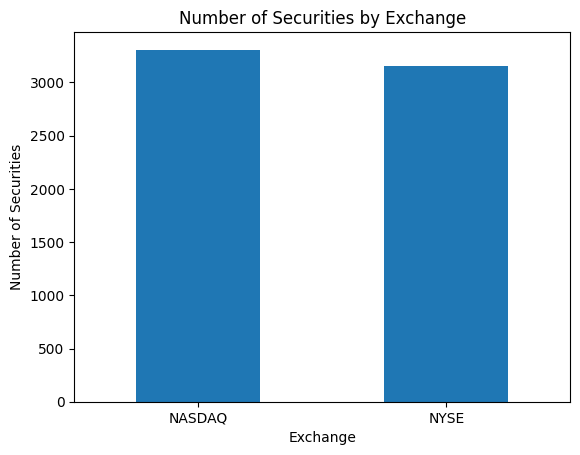

In [ ]:
# Create a bar chart
exchange_counts.plot(
kind='bar',
title='Number of Securities by Exchange',
xlabel='Exchange',
ylabel='Number of Securities',
rot=0
)

In [ ]:
# Find the exchange with the most securities
exchange_counts.idxmax(), exchange_counts.max()

('NASDAQ', 3308)

4.2 Sectors

In [ ]:
# Count securities by sector
sector_counts = df_stocks['sector'].value_counts()
sector_counts

,count
sector,
FINANCE,1022
CONSUMER SERVICES,796
HEALTH CARE,784
TECHNOLOGY,607
CAPITAL GOODS,352
ENERGY,286
PUBLIC UTILITIES,273
BASIC INDUSTRIES,272
CONSUMER NON-DURABLES,224


<Axes: title={'center': 'Number of Securities by Sector'}, xlabel='Sector', ylabel='Number of Securities'>

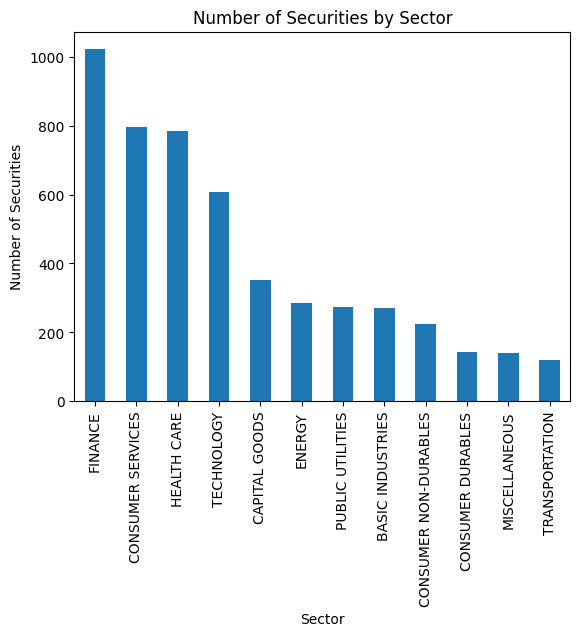

In [ ]:
# Create a bar chart
sector_counts.plot(
kind='bar',
title='Number of Securities by Sector',
xlabel='Sector',
ylabel='Number of Securities'
)

In [ ]:
# Count missing sector information
df_stocks['sector'].isna().sum()

np.int64(1440)

# 5. Explore Numerical Data

In [ ]:
# Select numerical variables
numerical_cols = ['open', 'high', 'low', 'close', 'volume']

In [ ]:
# Descriptive statistics
df_prices[numerical_cols].describe()

,open,high,low,close,volume
count,2.097389e+07,2.097389e+07,2.097389e+07,2.097389e+07,2.097389e+07
mean,7.605824e+01,7.803858e+01,7.422060e+01,7.611401e+01,1.227043e+06
std,2.848404e+03,2.996747e+03,2.744816e+03,2.868943e+03,1.316686e+07
min,4.000000e-04,4.000000e-04,1.000000e-04,2.000000e-04,1.000000e+00
25%,7.500000e+00,7.630000e+00,7.360000e+00,7.500000e+00,2.210000e+04
50%,1.545000e+01,1.566000e+01,1.524000e+01,1.545000e+01,1.260000e+05
75%,2.972000e+01,3.010000e+01,2.928000e+01,2.972000e+01,6.074000e+05
max,2.034000e+06,2.070000e+06,1.440000e+06,1.779750e+06,4.483504e+09


In [ ]:
# Calculate median
df_prices[numerical_cols].median()

,0
open,15.45
high,15.66
low,15.24
close,15.45
volume,126000.00


In [ ]:
# Mean and median closing price

print(df_prices['close'].mean())

print(df_prices['close'].median())

76.114006
15.449999809265137


In [ ]:
# Difference between mean and median closing price
df_prices['close'].mean() - df_prices['close'].median()

np.float32(60.664005)

In [ ]:
# Standard deviation
df_prices[numerical_cols].std()

,0
open,2.848404e+03
high,2.996747e+03
low,2.744816e+03
close,2.868943e+03
volume,1.316686e+07


In [ ]:
'''
Volume

'''

'\nVolume\n\n'

In [ ]:
# Maximum values
df_prices[numerical_cols].max()

,0
open,2.034000e+06
high,2.070000e+06
low,1.440000e+06
close,1.779750e+06
volume,4.483504e+09


In [ ]:
# Check records with the highest closing prices
df_prices.nlargest(10, 'close')[
['ticker', 'date', 'open', 'high', 'low', 'close', 'volume']
]

,ticker,date,open,high,low,close,volume
12146443,SCON,2000-02-28,1395000.000,1797750.0,1368000.00,1779750.0,400
12146459,SCON,2000-02-29,2034000.000,2070000.0,1440000.00,1595250.0,400
12146546,SCON,2000-03-13,900000.000,1404000.0,861750.00,1363500.0,300
17889354,CODA,2001-02-05,1354500.000,1736700.0,1354500.00,1354500.0,34
2444619,TVIX,2013-02-26,1375000.000,1542500.0,1300000.00,1347500.0,100
12146480,SCON,2000-03-02,1120500.000,1368000.0,1098280.75,1261125.0,200
12146437,SCON,2000-02-25,873561.625,1369125.0,873000.00,1215000.0,200
17107201,TOPS,2016-08-01,783000.000,1276200.0,783000.00,1189800.0,100
12146465,SCON,2000-03-01,1368000.000,1512000.0,1107000.00,1134000.0,300
12146562,SCON,2000-03-14,1352250.000,1354500.0,1080000.00,1111500.0,100


In [ ]:
# Check records with the highest trading volumes
df_prices.nlargest(10, 'volume')[
['ticker', 'date', 'open', 'high', 'low', 'close', 'volume']
]

,ticker,date,open,high,low,close,volume
1305719,FTAI,2012-01-31,759.700012,762.500000,759.700012,760.500000,4483504400
1308702,FTAI,2013-03-14,748.500000,749.299988,744.799988,745.299988,4214619800
1305866,FTAI,2012-02-21,822.000000,826.099976,820.299988,823.099976,4179398800
1300994,FTAI,2010-03-23,700.200012,702.400024,699.599976,702.400024,4102521400
1311076,FTAI,2014-01-17,884.099976,886.900024,883.299988,884.700012,4014023200
1312679,FTAI,2014-11-25,727.799988,730.000000,727.200012,729.799988,3871730200
1312762,FTAI,2014-12-08,714.400024,715.599976,713.099976,713.400024,3854617400
1305831,FTAI,2012-02-15,796.700012,802.200012,796.700012,801.799988,3702254400
1305595,FTAI,2012-01-13,734.200012,738.900024,733.900024,735.900024,3665033400
1310036,FTAI,2013-09-13,779.700012,781.799988,778.799988,780.799988,3645202600


# Part 6 Investigate Unusual Values

6.1 Investigate Unusual Values

In [ ]:
# Find the highest closing prices
highest_close = df_prices.nlargest(10, 'close')[
['ticker', 'date', 'open', 'high', 'low', 'close', 'volume']
]
highest_close

,ticker,date,open,high,low,close,volume
12146443,SCON,2000-02-28,1395000.000,1797750.0,1368000.00,1779750.0,400
12146459,SCON,2000-02-29,2034000.000,2070000.0,1440000.00,1595250.0,400
12146546,SCON,2000-03-13,900000.000,1404000.0,861750.00,1363500.0,300
17889354,CODA,2001-02-05,1354500.000,1736700.0,1354500.00,1354500.0,34
2444619,TVIX,2013-02-26,1375000.000,1542500.0,1300000.00,1347500.0,100
12146480,SCON,2000-03-02,1120500.000,1368000.0,1098280.75,1261125.0,200
12146437,SCON,2000-02-25,873561.625,1369125.0,873000.00,1215000.0,200
17107201,TOPS,2016-08-01,783000.000,1276200.0,783000.00,1189800.0,100
12146465,SCON,2000-03-01,1368000.000,1512000.0,1107000.00,1134000.0,300
12146562,SCON,2000-03-14,1352250.000,1354500.0,1080000.00,1111500.0,100


6.2 Adjusted Closing Price

In [ ]:
# Find the 10 highest adjusted closing prices
highest_adj_close = df_prices.nlargest(10, 'adj_close')[
['ticker', 'date', 'close', 'adj_close', 'volume']
]
highest_adj_close

,ticker,date,close,adj_close,volume
6174033,AAN,1987-02-27,1.296296,1.894962e+19,346900
6174039,AAN,1987-03-10,1.296296,1.894962e+19,20200
6174040,AAN,1987-03-11,1.296296,1.894962e+19,18900
6174041,AAN,1987-03-12,1.296296,1.894962e+19,27000
6174044,AAN,1987-03-17,1.296296,1.894962e+19,31000
6174045,AAN,1987-03-18,1.296296,1.894962e+19,272700
6174046,AAN,1987-03-19,1.296296,1.894962e+19,4000
6174049,AAN,1987-03-25,1.296296,1.894962e+19,184900
6174051,AAN,1987-03-27,1.287037,1.881428e+19,205200
6174050,AAN,1987-03-26,1.268519,1.854356e+19,20200


# Part 7: Visualize the Data

<Axes: title={'center': 'Distribution of Closing Prices'}, xlabel='Closing Price', ylabel='Frequency'>

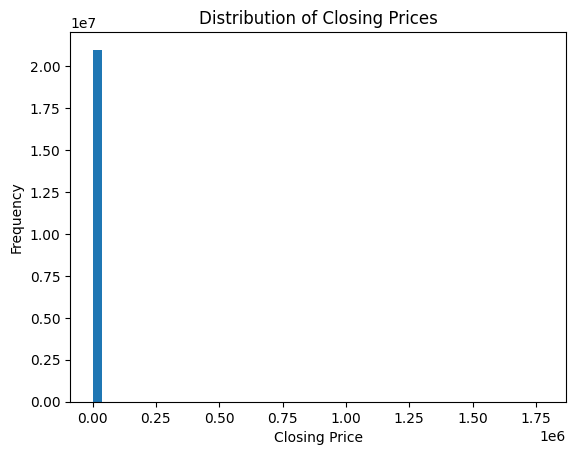

In [ ]:
# Closing price histogram

# Closing price histogram
df_prices['close'].plot(
kind='hist',
bins=50,
title='Distribution of Closing Prices',
xlabel='Closing Price'
)

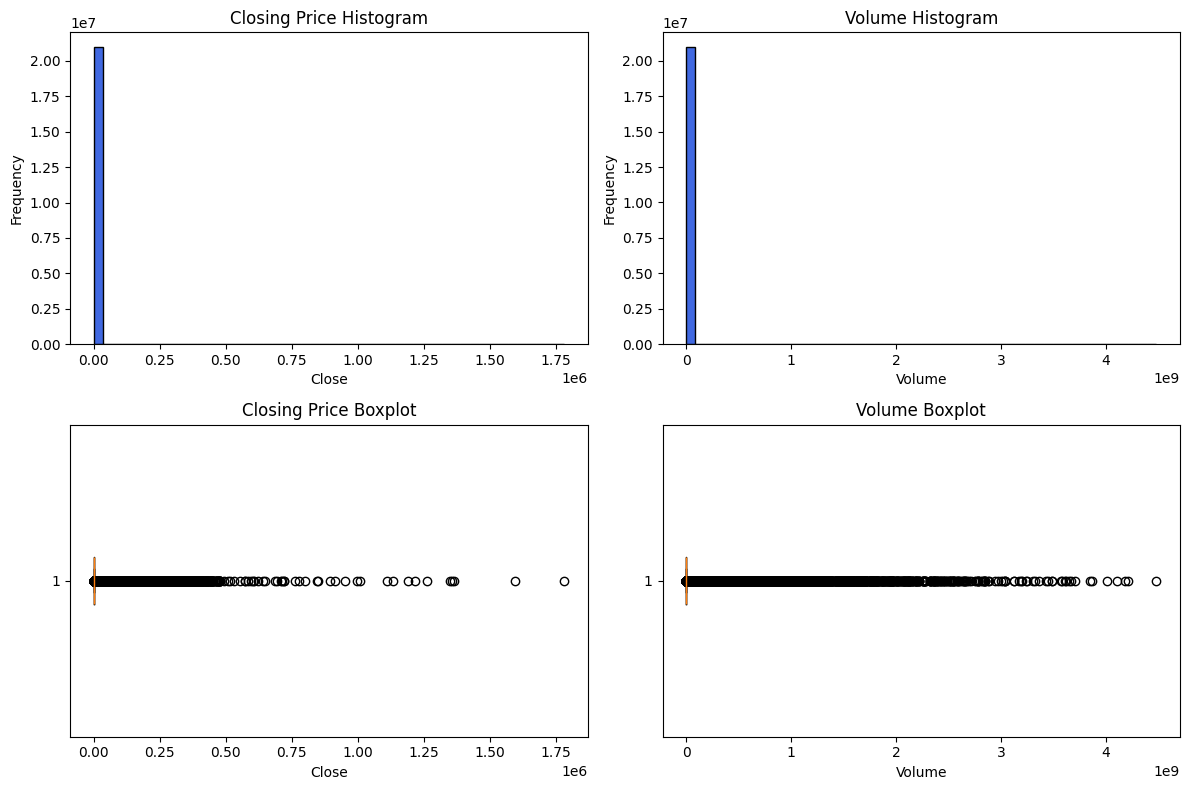

In [ ]:
import matplotlib.pyplot as plt

# Create 2 x 2 figure
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Closing Price Histogram
axes[0, 0].hist(df_prices['close'], bins=50, color='royalblue', edgecolor='black')
axes[0, 0].set_title('Closing Price Histogram')
axes[0, 0].set_xlabel('Close')
axes[0, 0].set_ylabel('Frequency')

# Volume Histogram
axes[0, 1].hist(df_prices['volume'], bins=50, color='royalblue', edgecolor='black')
axes[0, 1].set_title('Volume Histogram')
axes[0, 1].set_xlabel('Volume')
axes[0, 1].set_ylabel('Frequency')

# Closing Price Boxplot
axes[1, 0].boxplot(df_prices['close'], vert=False)
axes[1, 0].set_title('Closing Price Boxplot')
axes[1, 0].set_xlabel('Close')

# Volume Boxplot
axes[1, 1].boxplot(df_prices['volume'], vert=False)
axes[1, 1].set_title('Volume Boxplot')
axes[1, 1].set_xlabel('Volume')

# Adjust spacing
plt.tight_layout()
plt.show()

# Part 8: Explore One Stock

In [ ]:
# Choose a ticker
# Find tickers with the most price observations
df_prices['ticker'].value_counts().head(10)

,count
ticker,
GT,12274
CNP,12274
MRK,12274
XOM,12274
ED,12274
MRO,12274
PG,12274
ARNC,12274
JNJ,12274


In [ ]:
'''
# Let's explore the MMM stock.

'''

"\n# Let's explore the MMM stock.\n\n"

In [ ]:
# Select MMM stock
selected_ticker = 'MMM'

mmm = df_prices.loc[
df_prices['ticker'] == selected_ticker
].copy()

mmm.head()

,ticker,open,close,adj_close,low,high,volume,date
1669485,MMM,6.851562,6.851562,0.438697,6.843750,6.890625,72000,1970-01-02
1669493,MMM,6.859375,6.890625,0.441198,6.859375,6.898438,446400,1970-01-05
1669494,MMM,6.890625,6.960938,0.445700,6.882812,6.960938,176000,1970-01-06
1669495,MMM,6.960938,7.000000,0.448201,6.945312,7.015625,164800,1970-01-07
1669496,MMM,7.000000,7.093750,0.454204,6.984375,7.109375,304000,1970-01-08


In [ ]:
# Sort observations by date
mmm = mmm.sort_values('date')

In [ ]:
# Check MMM date range
mmm['date'].min(), mmm['date'].max()


(Timestamp('1970-01-02 00:00:00'), Timestamp('2018-08-24 00:00:00'))

<Axes: title={'center': 'MMM Closing Price Over Time'}, xlabel='Date', ylabel='Closing Price'>

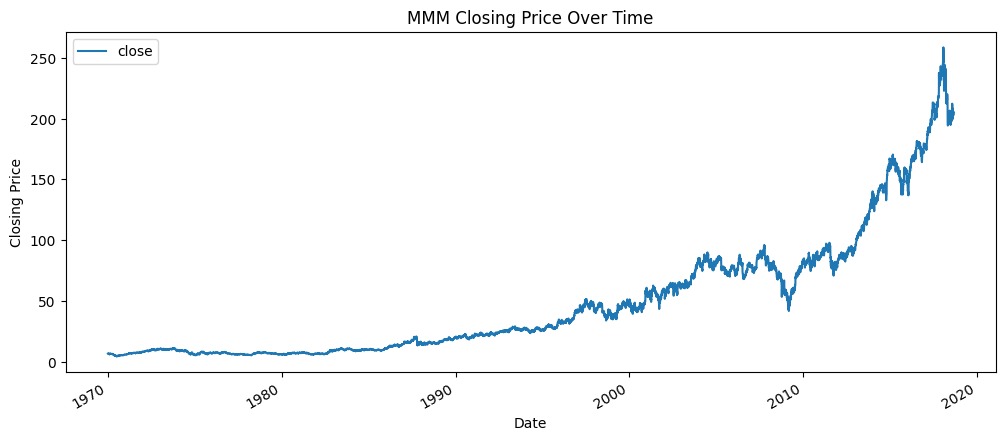

In [ ]:
# MMM closing price over time
mmm.plot(
x='date',
y='close',
kind='line',
figsize=(12, 5),
title='MMM Closing Price Over Time',
xlabel='Date',
ylabel='Closing Price'
)

In [ ]:
# Check unusually high prices
# Highest MMM closing prices
mmm.nlargest(5, 'close')[
['date', 'close', 'volume']
]

,date,close,volume
1790018,2018-01-26,258.630005,3730600
1790019,2018-01-29,256.010010,2306300
1790017,2018-01-25,252.360001,3507900
1790020,2018-01-30,251.539993,2412600
1790021,2018-01-31,250.500000,3136400


In [ ]:
# Lowest MMM closing prices
mmm.nsmallest(5, 'close')[
['date', 'close', 'volume']
]

,date,close,volume
1670566,1970-07-07,4.468750,486400
1670558,1970-07-06,4.484375,419200
1670538,1970-07-01,4.593750,286400
1670546,1970-07-02,4.609375,336000
1670606,1970-07-13,4.617188,252800


In [ ]:
# Calculate gaps between trading dates
mmm['date_gap'] = mmm['date'].diff()
mmm.head()

,ticker,open,close,adj_close,low,high,volume,date,date_gap
1669485,MMM,6.851562,6.851562,0.438697,6.843750,6.890625,72000,1970-01-02,NaT
1669493,MMM,6.859375,6.890625,0.441198,6.859375,6.898438,446400,1970-01-05,3 days
1669494,MMM,6.890625,6.960938,0.445700,6.882812,6.960938,176000,1970-01-06,1 days
1669495,MMM,6.960938,7.000000,0.448201,6.945312,7.015625,164800,1970-01-07,1 days
1669496,MMM,7.000000,7.093750,0.454204,6.984375,7.109375,304000,1970-01-08,1 days


In [ ]:
# Check large gaps in available data
mmm.loc[
mmm['date_gap'] > pd.Timedelta(days=7),
['date', 'date_gap']
]

,date,date_gap


# 9. Save the dataset

In [ ]:
# Define paths for cleaned datasets
stock_cleaned_path = '/content/drive/MyDrive/Drive_Colab/historical_stocks_cleaned.csv'

prices_cleaned_path = '/content/drive/MyDrive/Drive_Colab/historical_stock_prices_cleaned.csv'

In [ ]:
# Save cleaned datasets to Google Drive
df_stocks.to_csv(stock_cleaned_path, index=False)

#df_prices.to_csv(prices_cleaned_path, index=False)

In [ ]:
# Verify the save

print("Stocks saved to:", stock_cleaned_path)
print("Prices saved to:", prices_cleaned_path)

Stocks saved to: /content/drive/MyDrive/Drive_Colab/historical_stocks_cleaned.csv
Prices saved to: /content/drive/MyDrive/Drive_Colab/historical_stock_prices_cleaned.csv


In [ ]:
# Save large price dataset as Parquet
df_prices.to_parquet(
'/content/drive/MyDrive/Drive_Colab/historical_stock_prices_cleaned.parquet',
index=False
)